In [194]:
import numpy as np
import pandas as pd
from scipy import stats

In [195]:
# Gas properties
gases = ['Air', 'Helium', 'CO2', 'Hydrogen', 'Nitrogen', 'Oxygen', 'Methane', 'Argon', 'Ammonia', 'SO2', 'Ethylene', 'Propane']
molar_mass = {
    'Air': 0.029, 'Helium': 0.004, 'CO2': 0.044, 'Hydrogen': 0.002, 'Nitrogen': 0.028,
    'Oxygen': 0.032, 'Methane': 0.016, 'Argon': 0.040, 'Ammonia': 0.017, 'SO2': 0.064,
    'Ethylene': 0.028, 'Propane': 0.044
}
viscosity_ref = {
    200: {
        'Air': 1.33e-5, 'Helium': 1.54e-5, 'CO2': 1.02e-5, 'Hydrogen': 6.80e-6, 'Nitrogen': 1.31e-5,
        'Oxygen': 1.48e-5, 'Methane': 8.00e-6, 'Argon': 1.64e-5, 'Ammonia': 7.50e-6, 'SO2': 8.70e-6,
        'Ethylene': 7.40e-6, 'Propane': 5.80e-6
    },
    250: {
        'Air': 1.56e-5, 'Helium': 1.76e-5, 'CO2': 1.24e-5, 'Hydrogen': 7.80e-6, 'Nitrogen': 1.53e-5,
        'Oxygen': 1.74e-5, 'Methane': 9.50e-6, 'Argon': 1.93e-5, 'Ammonia': 8.70e-6, 'SO2': 1.05e-5,
        'Ethylene': 8.80e-6, 'Propane': 7.00e-6
    },
    293: {
        'Air': 1.80e-5, 'Helium': 1.97e-5, 'CO2': 1.47e-5, 'Hydrogen': 8.90e-6, 'Nitrogen': 1.76e-5,
        'Oxygen': 2.02e-5, 'Methane': 1.10e-5, 'Argon': 2.23e-5, 'Ammonia': 1.00e-5, 'SO2': 1.24e-5,
        'Ethylene': 1.03e-5, 'Propane': 8.20e-6
    },
    350: {
        'Air': 2.03e-5, 'Helium': 2.21e-5, 'CO2': 1.74e-5, 'Hydrogen': 1.00e-5, 'Nitrogen': 1.98e-5,
        'Oxygen': 2.30e-5, 'Methane': 1.28e-5, 'Argon': 2.52e-5, 'Ammonia': 1.16e-5, 'SO2': 1.45e-5,
        'Ethylene': 1.20e-5, 'Propane': 9.60e-6
    },
    400: {
        'Air': 2.22e-5, 'Helium': 2.41e-5, 'CO2': 1.96e-5, 'Hydrogen': 1.10e-5, 'Nitrogen': 2.16e-5,
        'Oxygen': 2.52e-5, 'Methane': 1.42e-5, 'Argon': 2.76e-5, 'Ammonia': 1.28e-5, 'SO2': 1.62e-5,
        'Ethylene': 1.33e-5, 'Propane': 1.07e-5
    }
}
sutherland_C = {
    200: {
        'Air': 110.4, 'Helium': 79.4, 'CO2': 240, 'Hydrogen': 72, 'Nitrogen': 111,
        'Oxygen': 127, 'Methane': 170, 'Argon': 144, 'Ammonia': 370, 'SO2': 416,
        'Ethylene': 224, 'Propane': 264
    },
    250: {
        'Air': 110.4, 'Helium': 79.4, 'CO2': 240, 'Hydrogen': 72, 'Nitrogen': 111,
        'Oxygen': 127, 'Methane': 170, 'Argon': 144, 'Ammonia': 370, 'SO2': 416,
        'Ethylene': 224, 'Propane': 264
    },
    293: {
        'Air': 110.4, 'Helium': 79.4, 'CO2': 240, 'Hydrogen': 72, 'Nitrogen': 111,
        'Oxygen': 127, 'Methane': 170, 'Argon': 144, 'Ammonia': 370, 'SO2': 416,
        'Ethylene': 224, 'Propane': 264
    },
    350: {
        'Air': 110.4, 'Helium': 79.4, 'CO2': 240, 'Hydrogen': 72, 'Nitrogen': 111,
        'Oxygen': 127, 'Methane': 170, 'Argon': 144, 'Ammonia': 370, 'SO2': 416,
        'Ethylene': 224, 'Propane': 264
    },
    400: {
        'Air': 110.4, 'Helium': 79.4, 'CO2': 240, 'Hydrogen': 72, 'Nitrogen': 111,
        'Oxygen': 127, 'Methane': 170, 'Argon': 144, 'Ammonia': 370, 'SO2': 416,
        'Ethylene': 224, 'Propane': 264
    }
}
critical_points = {
    'Air': (132.5, 37.2 * 101325), 'Helium': (5.2, 2.24 * 101325), 'CO2': (304.2, 73.8 * 101325),
    'Hydrogen': (33.2, 12.8 * 101325), 'Nitrogen': (126.2, 33.5 * 101325), 'Oxygen': (154.6, 50.4 * 101325),
    'Methane': (190.6, 45.4 * 101325), 'Argon': (150.7, 48.0 * 101325), 'Ammonia': (405.6, 111.3 * 101325),
    'SO2': (430.8, 77.8 * 101325), 'Ethylene': (282.4, 49.7 * 101325), 'Propane': (369.8, 41.9 * 101325)
}

In [196]:
# Constants
R = 8.314  # Universal gas constant (J/mol·K)
reference_temps = [200, 250, 293, 350, 400]

In [197]:
def calculate_viscosity(gas, T):
    """Calculate viscosity using Sutherland's formula."""
    T_ref = min(reference_temps, key=lambda x: abs(x - T))
    mu_0 = viscosity_ref[T_ref][gas]
    C = sutherland_C[T_ref][gas]
    return mu_0 * ((T / T_ref) ** 1.5) * ((T_ref + C) / (T + C))

def is_gaseous(row):
    """Check if gas remains in gaseous state (avoid liquefaction)."""
    Tc, Pc = critical_points[row['Gas']]
    return (row['Temperature'] > 1.2 * Tc) or (row['Pressure'] < 0.4 * Pc)

def generate_data(n, min_re, max_re, velocity_range, diameter_range, gases_subset, temp_range=(200, 400)):
    """Generate gas flow data without log transformations."""
    data = {
        'Gas': np.random.choice(gases_subset, n),
        'Temperature': np.random.uniform(temp_range[0], temp_range[1], n),
        'Pressure': np.random.uniform(0.1, 10, n) * 101325,
        'Velocity': np.random.uniform(velocity_range[0], velocity_range[1], n),
        'Diameter': np.random.uniform(diameter_range[0], diameter_range[1], n)
    }
    df = pd.DataFrame(data)

    # Calculate density and viscosity
    df['Density'] = df.apply(lambda x: (x['Pressure'] * molar_mass[x['Gas']]) / (R * x['Temperature']), axis=1)
    df['Viscosity'] = df.apply(lambda x: calculate_viscosity(x['Gas'], x['Temperature']), axis=1)

    # Calculate Re
    df['Re'] = df['Density'] * df['Velocity'] * df['Diameter'] / df['Viscosity']

    # Assign flow regime
    df['Flow_Regime'] = df['Re'].apply(lambda x: 'Laminar' if x < 2300 else 'Transitional' if x < 4000 else 'Turbulent')

    # Filter by Re range
    df = df[(df['Re'] >= min_re) & (df['Re'] < max_re)]

    return df

In [198]:
# Parameters
n_per_regime = 1000000
target_samples = 150000
np.random.seed(42)

In [199]:
# Standard gases (exclude Hydrogen, Helium for separate handling)
standard_gases = [g for g in gases if g not in ['Hydrogen', 'Helium']]
# Laminar: Re < 2300
laminar_df = generate_data(n_per_regime, 0, 2300, velocity_range=(0.01, 1.0), diameter_range=(0.0001, 0.01), gases_subset=standard_gases)
# Transitional: 2300 <= Re < 4000
transitional_df = generate_data(n_per_regime, 2300, 4000, velocity_range=(0.1, 2.0), diameter_range=(0.001, 0.05), gases_subset=standard_gases)
# Turbulent: Re >= 4000
turbulent_df = generate_data(n_per_regime, 4000, 1e7, velocity_range=(1.0, 50.0), diameter_range=(0.01, 0.5), gases_subset=standard_gases)

In [200]:
# Hydrogen and Helium (low Tc, separate temp range)
low_tc_gases = ['Hydrogen', 'Helium']
laminar_low_tc = generate_data(n_per_regime, 0, 2300, velocity_range=(0.01, 1.0), diameter_range=(0.0001, 0.01), gases_subset=low_tc_gases, temp_range=(50, 200))
transitional_low_tc = generate_data(n_per_regime, 2300, 4000, velocity_range=(0.1, 2.0), diameter_range=(0.001, 0.05), gases_subset=low_tc_gases, temp_range=(50, 200))
turbulent_low_tc = generate_data(n_per_regime, 4000, 1e7, velocity_range=(1.0, 50.0), diameter_range=(0.01, 0.5), gases_subset=low_tc_gases, temp_range=(50, 200))

In [201]:
# Combine and apply phase filter
df_list = [laminar_df, transitional_df, turbulent_df, laminar_low_tc, transitional_low_tc, turbulent_low_tc]
df_list = [df[df.apply(is_gaseous, axis=1)] for df in df_list]

In [202]:
# Subsample to balance regimes and gases
def balance_gases(df, target_per_gas=12500):  # 150000 / 12 gases = 12500
    gas_dfs = []
    for gas in gases:
        gas_df = df[df['Gas'] == gas]
        n_samples = min(len(gas_df), target_per_gas)
        if n_samples > 0:
            gas_dfs.append(gas_df.sample(n=n_samples, random_state=42))
    return pd.concat(gas_dfs, ignore_index=True)

In [203]:
# Combine standard and low-Tc gases
laminar_df = balance_gases(pd.concat([df_list[0], df_list[3]], ignore_index=True))
transitional_df = balance_gases(pd.concat([df_list[1], df_list[4]], ignore_index=True))
turbulent_df = balance_gases(pd.concat([df_list[2], df_list[5]], ignore_index=True))

In [204]:
# Combine final dataset
df = pd.concat([laminar_df, transitional_df, turbulent_df], ignore_index=True)

In [205]:
# Physical constraints to remove outliers
df = df[df['Re'] < 1e7]
df = df[df['Pressure'] <= 10 * 101325]
df = df[df['Velocity'] < 343]  # Subsonic speeds
df = df[df['Density'] > 0]
df = df[df['Viscosity'] > 0]

In [206]:
# Statistical outlier removal
features = ['Density', 'Velocity', 'Diameter', 'Viscosity', 'Re']
z_scores = np.abs(stats.zscore(df[features]))
df = df[(z_scores < 3).all(axis=1)]

In [207]:
# Ensure exactly 150,000 samples per regime
def balance_regimes(df, regime, target):
    regime_df = df[df['Flow_Regime'] == regime]
    if len(regime_df) > target:
        return regime_df.sample(n=target, random_state=42)
    return regime_df

In [208]:
laminar_final = balance_regimes(df, 'Laminar', 150000)
transitional_final = balance_regimes(df, 'Transitional', 150000)
turbulent_final = balance_regimes(df, 'Turbulent', 150000)

In [218]:
# Final dataset
df_final = pd.concat([laminar_final, transitional_final, turbulent_final], ignore_index=True)

In [219]:
# Save to CSV
df_final.to_csv('reynolds_gas_dataset.csv', index=False)

In [220]:
# Display results
print("Gas Dataset Head:")
print(df_final.head())
print("\nDataset Shape:", df_final.shape)

Gas Dataset Head:
   Gas  Temperature      Pressure  Velocity  Diameter    Density  Viscosity  \
0  Air   341.506957  1.355832e+05  0.130221  0.007435   1.384824   0.000020   
1  Air   261.428119  8.453040e+05  0.085557  0.001278  11.278429   0.000016   
2  Air   327.889256  7.060931e+05  0.354320  0.006348   7.511432   0.000019   
3  Air   261.985288  1.001137e+06  0.189779  0.000711  13.329211   0.000016   
4  Air   301.983404  4.952753e+05  0.163252  0.000105   5.720731   0.000018   

           Re Flow_Regime  
0   67.265731     Laminar  
1   76.292507     Laminar  
2  873.769531     Laminar  
3  111.014811     Laminar  
4    5.328114     Laminar  

Dataset Shape: (413632, 9)


In [221]:
print("\nFlow Regime Distribution:")
print(df_final['Flow_Regime'].value_counts())


Flow Regime Distribution:
Flow_Regime
Laminar         147379
Turbulent       133332
Transitional    132921
Name: count, dtype: int64


In [222]:
print("\nGas Distribution:")
print(df_final['Gas'].value_counts())


Gas Distribution:
Gas
Helium      36980
Hydrogen    36886
Methane     36756
Oxygen      36650
Air         36615
Nitrogen    36597
Ammonia     36519
Argon       35780
Ethylene    33671
CO2         32317
Propane     28988
SO2         25873
Name: count, dtype: int64


In [223]:
print("\nSummary Statistics:")
print(df_final[features].describe())


Summary Statistics:
             Density       Velocity       Diameter      Viscosity  \
count  413632.000000  413632.000000  413632.000000  413632.000000   
mean        4.903178       8.043932       0.084796       0.000014   
std         4.071355      13.316281       0.131370       0.000006   
min         0.013250       0.010008       0.000100       0.000002   
25%         1.635580       0.427136       0.005536       0.000010   
50%         3.760957       0.899080       0.017262       0.000013   
75%         7.178735      10.295710       0.103739       0.000018   
max        19.396614      49.999947       0.499994       0.000028   

                 Re  
count  4.136320e+05  
mean   5.264054e+05  
std    1.163561e+06  
min    8.332664e-02  
25%    8.276393e+02  
50%    2.987634e+03  
75%    3.191865e+05  
max    6.009822e+06  


In [224]:
# Check for invalid values
print("\nNaN Values:")
print(df_final.isna().sum())
print("\nInfinite Values:")
print(np.isinf(df_final[features]).sum())


NaN Values:
Gas            0
Temperature    0
Pressure       0
Velocity       0
Diameter       0
Density        0
Viscosity      0
Re             0
Flow_Regime    0
dtype: int64

Infinite Values:
Density      0
Velocity     0
Diameter     0
Viscosity    0
Re           0
dtype: int64


In [225]:
# Check near liquefaction
df_final['Near_Liquefaction'] = df_final.apply(lambda row: (row['Temperature'] < 1.3 * critical_points[row['Gas']][0]) and (row['Pressure'] > 0.3 * critical_points[row['Gas']][1]), axis=1)
print("\nSamples Near Liquefaction:")
print(df_final['Near_Liquefaction'].value_counts())


Samples Near Liquefaction:
Near_Liquefaction
False    413632
Name: count, dtype: int64


In [226]:
# Feature correlations
print("\nFeature Correlations:")
corr_matrix = df_final[features].corr()
print(corr_matrix)


Feature Correlations:
            Density  Velocity  Diameter  Viscosity        Re
Density    1.000000 -0.038377 -0.052374   0.263982  0.189702
Velocity  -0.038377  1.000000  0.597675   0.003141  0.686483
Diameter  -0.052374  0.597675  1.000000   0.005153  0.680074
Viscosity  0.263982  0.003141  0.005153   1.000000 -0.027990
Re         0.189702  0.686483  0.680074  -0.027990  1.000000


In [254]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats

In [255]:
gas_df = pd.read_csv('/content/reynolds_gas_dataset.csv')

In [256]:
gas_df

,Gas,Temperature,Pressure,Velocity,Diameter,Density,Viscosity,Re,Flow_Regime
0,Air,341.506957,1.355832e+05,0.130221,0.007435,1.384824,0.000020,6.726573e+01,Laminar
1,Air,261.428119,8.453040e+05,0.085557,0.001278,11.278429,0.000016,7.629251e+01,Laminar
2,Air,327.889256,7.060931e+05,0.354320,0.006348,7.511432,0.000019,8.737695e+02,Laminar
3,Air,261.985288,1.001137e+06,0.189779,0.000711,13.329211,0.000016,1.110148e+02,Laminar
4,Air,301.983404,4.952753e+05,0.163252,0.000105,5.720731,0.000018,5.328114e+00,Laminar
...,...,...,...,...,...,...,...,...,...
413627,Propane,222.418045,8.303759e+04,32.675658,0.201262,1.975820,0.000006,2.002564e+06,Turbulent
413628,Propane,296.849659,8.329009e+04,38.052365,0.132908,1.484908,0.000008,9.042894e+05,Turbulent
413629,Propane,391.024768,2.551761e+04,8.758681,0.207295,0.345365,0.000010,5.981305e+04,Turbulent
413630,Propane,261.815756,2.222388e+04,4.472423,0.337053,0.449228,0.000007,9.234152e+04,Turbulent


In [257]:
X = gas_df[['Density', 'Velocity', 'Diameter', 'Viscosity']].values
y = gas_df['Re'].values

In [258]:
X_log = np.log1p(X)
y_log = np.log1p(y)

In [259]:
print("NaN in X:", np.any(np.isnan(X)))
print("NaN in y:", np.any(np.isnan(y)))
print("Infinite in X:", np.any(np.isinf(X)))
print("Infinite in y:", np.any(np.isinf(y)))

NaN in X: False
NaN in y: False
Infinite in X: False
Infinite in y: False


In [260]:
print("Min Re:", np.min(y))
print("Max Re:", np.max(y))
print("Min log(Re):", np.min(y_log))
print("Max log(Re):", np.max(y_log))

Min Re: 0.0833266406215176
Max Re: 6009822.0143320495
Min log(Re): 0.08003652976662329
Max log(Re): 15.608905857547333


In [261]:
z_scores = np.abs(stats.zscore(X_log))
outliers = (z_scores > 3).any(axis=1)
print(f"Number of outliers: {np.sum(outliers)}")

Number of outliers: 0


In [262]:
# Filter out outliers
gas_df_clean = gas_df[~outliers]
X_clean = X[~outliers]
y_clean = y[~outliers]
X_log_clean = X_log[~outliers]
y_log_clean = y_log[~outliers]

# Verify dataset after outlier removal
print("Dataset Shape after Outlier Removal:", gas_df_clean.shape)
print("NaN in X_clean:", np.any(np.isnan(X_clean)))
print("NaN in y_clean:", np.any(np.isnan(y_clean)))
print("Infinite in X_clean:", np.any(np.isinf(X_clean)))
print("Infinite in y_clean:", np.any(np.isinf(y_clean)))

Dataset Shape after Outlier Removal: (413632, 9)
NaN in X_clean: False
NaN in y_clean: False
Infinite in X_clean: False
Infinite in y_clean: False


In [265]:
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(X_log)
target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(y_log.reshape(-1, 1)).flatten()

In [266]:
# Display scaled data statistics
print("\nScaled Features Statistics:")
print(pd.DataFrame(X_scaled, columns=['Density', 'Velocity', 'Diameter', 'Viscosity']).describe())
print("\nScaled Target Statistics:")
print(pd.Series(y_scaled, name='Re').describe())


Scaled Features Statistics:
             Density       Velocity       Diameter      Viscosity
count  413632.000000  413632.000000  413632.000000  413632.000000
mean        0.507609       0.324216       0.184437       0.462403
std         0.235546       0.321837       0.273848       0.221801
min         0.000000       0.000000       0.000000       0.000000
25%         0.318413       0.088150       0.013373       0.298204
50%         0.515383       0.160998       0.041973       0.431662
75%         0.695613       0.615642       0.243249       0.633475
max         1.000000       1.000000       1.000000       1.000000

Scaled Target Statistics:
count    413632.000000
mean          0.576383
std           0.226397
min           0.000000
25%           0.427574
50%           0.510181
75%           0.810973
max           1.000000
Name: Re, dtype: float64


In [267]:
joblib.dump(feature_scaler, 'scaler_X.pkl')

['scaler_X.pkl']

In [268]:
joblib.dump(target_scaler, 'scaler_y.pkl')

['scaler_y.pkl']

In [269]:
gas_df_clean.to_csv('reynolds_gas_dataset_clean.csv', index=False)

In [282]:
print("X_scaled min:", np.min(X_scaled, axis=0))
print("X_scaled max:", np.max(X_scaled, axis=0))
print("y_scaled min:", np.min(y_scaled))
print("y_scaled max:", np.max(y_scaled))

X_scaled min: [0. 0. 0. 0.]
X_scaled max: [1. 1. 1. 1.]
y_scaled min: 0.0
y_scaled max: 0.9999999999999999


In [283]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [284]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((330905, 4), (82727, 4), (330905,), (82727,))

In [285]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [294]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

In [295]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5, # Stop after 5 epochs with no improvement
    min_delta=0.001,
    restore_best_weights=True  # Restore weights from the best epoch
)

In [296]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping]  # Add early stopping callback
)

Epoch 1/20
2586/2586 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 3.4486e-04 - mae: 0.0126 - val_loss: 2.6799e-04 - val_mae: 0.0115
Epoch 2/20
2586/2586 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2.4860e-04 - mae: 0.0111 - val_loss: 2.3159e-04 - val_mae: 0.0109
Epoch 3/20
2586/2586 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 2.2410e-04 - mae: 0.0106 - val_loss: 2.1593e-04 - val_mae: 0.0104
Epoch 4/20
2586/2586 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 2.0884e-04 - mae: 0.0103 - val_loss: 1.9837e-04 - val_mae: 0.0103
Epoch 5/20
2586/2586 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.8683e-04 - mae: 0.0099 - val_loss: 1.4952e-04 - val_mae: 0.0087
Epoch 6/20
2586/2586 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 1.4626e-04 - mae: 0.0087 - val_loss: 1.3753e-04 - val_mae: 0.0085


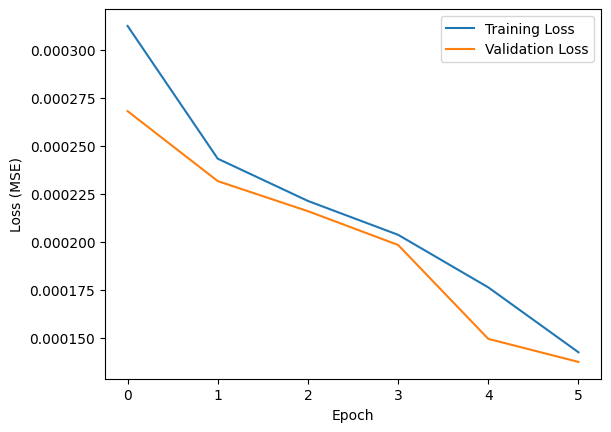

In [297]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [298]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE): {loss:.6f}, Test MAE: {mae:.6f}")

2586/2586 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 2.6346e-04 - mae: 0.0114
Test Loss (MSE): 0.000268, Test MAE: 0.011462


In [299]:
# Evaluate the model on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform predictions and true values to log scale
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

2586/2586 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [300]:
# Calculate metrics on log scale
rmse_log = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2_log = r2_score(y_test_orig, y_pred)
print(f"\nTest RMSE (log scale): {rmse_log}")
print(f"Test R² (log scale): {r2_log}")

# Convert predictions and true values back to original Re scale
y_pred_orig = np.expm1(y_pred)  # Inverse of log1p
y_test_orig_re = np.expm1(y_test_orig)  # Inverse of log1p

# Calculate metrics on original Re scale
rmse_orig = np.sqrt(mean_squared_error(y_test_orig_re, y_pred_orig))
r2_orig = r2_score(y_test_orig_re, y_pred_orig)
print(f"Test RMSE (original Re scale): {rmse_orig}")
print(f"Test R² (original Re scale): {r2_orig}")


Test RMSE (log scale): 0.25421417049185246
Test R² (log scale): 0.9947614556789667
Test RMSE (original Re scale): 150019.38961712888
Test R² (original Re scale): 0.9832550280450135


In [301]:
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_log = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_pred = np.expm1(y_pred_log)
y_test_log = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_test_original = np.expm1(y_test_log)

ss_total = np.sum((y_test_original - np.mean(y_test_original)) ** 2)
ss_residual = np.sum((y_test_original - y_pred) ** 2)
r2 = 1 - (ss_residual / ss_total)
print(f"R² Score: {r2:.6f}")

epsilon = 1e-10
mape = 100 * np.mean(np.abs((y_test_original - y_pred) / (y_test_original + epsilon)))
print(f"MAPE (%): {mape:.2f}%")

mse_original = np.mean((y_pred - y_test_original) ** 2)
mae_original = np.mean(np.abs(y_pred - y_test_original))
print(f"MSE on original scale: {mse_original:.2f}")
print(f"MAE on original scale: {mae_original:.2f}")

print("\nSample Predictions vs Actual Values:")
for i in range(5):
    print(f"Predicted Re: {y_pred[i]:.2f}, Actual Re: {y_test_original[i]:.2f}")

R² Score: 0.983255
MAPE (%): 20.22%
MSE on original scale: 22505817261.10
MAE on original scale: 53985.36

Sample Predictions vs Actual Values:
Predicted Re: 299997.34, Actual Re: 288954.13
Predicted Re: 228.24, Actual Re: 271.13
Predicted Re: 393.91, Actual Re: 468.88
Predicted Re: 404.25, Actual Re: 326.25
Predicted Re: 2559733.25, Actual Re: 2950347.56


In [302]:
# Save model and scalers
model.save('reynolds_model_gas.h5')
joblib.dump(feature_scaler, 'feature_scaler_gas.pkl')
joblib.dump(target_scaler, 'target_scaler_gas.pkl')

['target_scaler_gas.pkl']

In [304]:
import json

In [305]:
gaseous_df = pd.read_csv('reynolds_gas_dataset_clean.csv')

In [307]:
# Features for sliders
features = ['Density', 'Velocity', 'Diameter', 'Viscosity']

# Compute min and max with a 5% buffer
ranges = {'gas': {}}

for feature in features:
    min_val = gaseous_df[feature].min()
    max_val = gaseous_df[feature].max()
    buffer = 0.05 * (max_val - min_val)
    ranges['gas'][feature] = {
        'min': max(0, min_val - buffer),  # Ensure non-negative
        'max': max_val + buffer,
        'step': (max_val - min_val) / 1000  # Fine-grained steps
    }

In [308]:
# Save ranges to JSON
with open('gas_slider_ranges.json', 'w') as f:
    json.dump(ranges, f, indent=4)

In [310]:
# Display summary statistics for verification
print("\nSummary Statistics of Features:")
print(gaseous_df[features].describe())


Summary Statistics of Features:
             Density       Velocity       Diameter      Viscosity
count  413632.000000  413632.000000  413632.000000  413632.000000
mean        4.903178       8.043932       0.084796       0.000014
std         4.071355      13.316281       0.131370       0.000006
min         0.013250       0.010008       0.000100       0.000002
25%         1.635580       0.427136       0.005536       0.000010
50%         3.760957       0.899080       0.017262       0.000013
75%         7.178735      10.295710       0.103739       0.000018
max        19.396614      49.999947       0.499994       0.000028


In [312]:
# Print ranges for verification
print("Slider Ranges for Gaseous Dataset:")
print(json.dumps(ranges, indent=4))

Slider Ranges for Gaseous Dataset:
{
    "gas": {
        "Density": {
            "min": 0,
            "max": 20.36578206659651,
            "step": 0.019383363913364544
        },
        "Velocity": {
            "min": 0,
            "max": 52.499443580940465,
            "step": 0.049989938890054514
        },
        "Diameter": {
            "min": 0,
            "max": 0.5249885104741552,
            "step": 0.0004998937567777777
        },
        "Viscosity": {
            "min": 6.100923200764568e-07,
            "max": 2.8885055939928103e-05,
            "step": 2.5704512381683317e-08
        }
    }
}
